# Đề cập lại bài toán
- Bài toán ban đầu của nhóm là phân tích và dự đoán giá nhà ở 2 thành phố lớn là Hồ Chí Minh và Hà Nội nên nhóm sẽ xây dựng mô hình để dự đoán giá nhà


# Xây dựng mô hình

## Chuẩn bị dữ liệu chung cho cả 2 mô hình

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/unified/preprocessed_merged.csv')
df = df.drop_duplicates(inplace=False)
df = df[(df['gia'] >= 0.5) & (df['gia'] <=500) & (df['so_tang'] <= 16) & (df['phong_ngu'] <= 30) & (df['phong_tam'] <= 30) & (df['dien_tich_dat'] <= 3000) & (df['dien_tich_dat'] > 5) & df['gia_tren_m2'] > 0]

Chia tập dữ liệu thành 80/20 với tương ứng với tập train/test 

In [8]:
# Giả sử cột target là 'price'
X = df.drop('gia', axis=1)
y = df['gia']

# Chia dữ liệu thành tập train và test với tỉ lệ 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Mô hình 1
- Mô hình 1 sẽ dùng một biến kết hợp đó là quan x dien_tich_dat và cộng với diem_sinh_loi trong đó
- quan x dien_tich_dat là One hot encoding quận sau đó nhân với diện tích đất để ra biến mới, lý do kết hợp như này vì phần lớn giá nhà ở các trung tâm như Hà Nội và Hồ Chí Minh phụ thuộc rất nhiều vào vị trí, có những căn nhà vài mét vuông nhưng ở vị trí đắt đỏ lại có thể bán được vài tỷ [[1]](https://cafef.vn/con-duong-dat-do-bac-nhat-viet-nam-gia-nha-len-toi-3-ty-dong-m2-188240921095104835.chn) nên ý tưởng là thay vì chỉ quan tâm đến giá theo diện tích đất chung ta sẽ quan tâm đến giá theo diện tích đất theo từng quận sau đó cộng với diem_sinh_loi vì biến này được tính theo số phòng ngủ,số phòng tắm, số tầng,... vì thế cũng sẽ khái quát được độ lớn của ngôi nhà nên cũng sẽ ảnh hưởng đến giá.
- Do vậy 2 feature này sẽ tổng quát được vị trí theo giá và độ lớn của ngôi nhà



In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

# --- Tạo feature như mô tả ---

# One-hot encoding cho "quan"
quan_dummies = pd.get_dummies(X_train['quan'], prefix='quan')
quan_dummies_test = pd.get_dummies(X_test['quan'], prefix='quan')


# Đảm bảo các cột quận giống nhau giữa train và test (tránh missing columns)
quan_dummies, quan_dummies_test = quan_dummies.align(quan_dummies_test, join='left', axis=1, fill_value=0)

# feature: quan x dien_tich_dat
for col in quan_dummies.columns:
    X_train[f"{col}_x_dien_tich_dat"] = quan_dummies[col] * X_train['dien_tich_dat']
    X_test[f"{col}_x_dien_tich_dat"] = quan_dummies_test[col] * X_test['dien_tich_dat']


# Tạo feature đầu ra cuối cùng: tất cả các "quan x dien_tich_dat" + diem_sinh_loi + các feature phap_ly + các feature thanh_pho
feature_cols = [c for c in X_train.columns if '_x_dien_tich_dat' in c]
feature_cols.append('diem_sinh_loi')

X_train_features = X_train[feature_cols].copy()
X_test_features = X_test[feature_cols].copy()

# --- So sánh mô hình ---

results = {}

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_features, y_train)
y_pred_lr = lin_reg.predict(X_test_features)
results['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R2': r2_score(y_test, y_pred_lr)
}

# Random Forest
rf = RandomForestRegressor(
    #n_estimators=500,
    random_state=42)
rf.fit(X_train_features, y_train)
y_pred_rf = rf.predict(X_test_features)
results['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
}

# Hiển thị kết quả
print("So sánh 2 thuật toán:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"    RMSE: {metrics['RMSE']:.2f}")
    print(f"    MAE:  {metrics['MAE']:.2f}")
    print(f"    R2:   {metrics['R2']:.4f}")



So sánh 2 thuật toán:
Linear Regression:
    RMSE: 14.80
    MAE:  6.56
    R2:   0.7186
Random Forest:
    RMSE: 17.18
    MAE:  6.01
    R2:   0.6208


### Nhận xét chi tiết về kết quả so sánh 2 thuật toán của mô hình 1

#### 1. Phân tích các chỉ số đánh giá của 2 thuật toán

##### 1.1. Root Mean Squared Error (RMSE)
**Linear Regression: 14.8  | Random Forest: 17.10**

- Linear Regression có RMSE thấp hơn so với Random Forest, cho thấy mô hình tuyến tính dự đoán chính xác hơn về tổng thể.
- RMSE là chỉ số nhạy cảm với các giá trị outliers do sử dụng bình phương sai số. Việc Linear Regression có RMSE thấp hơn cho thấy mô hình này xử lý tốt các trường hợp có sai số lớn

##### 1.2. Mean Absolute Error (MAE)
**Linear Regression: 6.56 | Random Forest: 5.96**

- Random Forest có MAE thấp hơn so với Linear Regression - đây là ưu điểm đáng kể
- MAE phản ánh sai số trung bình thực tế mà người dùng sẽ gặp phải. Với Random Forest, trung bình một dự đoán sai lệch khoảng 5.96, trong khi Linear Regression sai lệch 6.56
- Sự chênh lệch này (0.6) là có ý nghĩa trong thực tế, đặc biệt với các căn nhà giá trung bình
- MAE thấp hơn của Random Forest thấp hơn nhưng RMSE lại cao hơn so với Linear Regression cho thấy mô hình này dự đoán tốt hơn với **phần lớn các trường hợp thông thường**, nhưng có thể RF overfit vào vài vùng dữ liệu hiếm  (ví dụ quận ít mẫu, diện tích rất lớn/nhỏ, điểm sinh lợi cực trị), dẫn tới dự đoán cho các điểm hiếm này cực kỳ lệch vì thế RMSE lại cao hơn trong khi MAE thấp hơn

##### 1.3. R² Score (Hệ số xác định)
**Linear Regression: 0.7186 | Random Forest: 0.6244**

- Linear Regression giải thích được **71.86%** biến động của giá nhà, cao hơn Random Forest (**62.08%**)
- Chênh lệch **9.42%** trong R² là đáng kể, cho thấy Linear Regression nắm bắt được mối quan hệ tổng thể tốt hơn
- R² > 0.6 cho cả hai mô hình là kết quả khá tốt trong bài toán dự đoán giá bất động sản, vốn chịu ảnh hưởng của nhiều yếu tố không quan sát được
- Việc Linear Regression đạt R² cao hơn cho thấy **feature engineering đã thực hiện (quan × diện_tích_đất) có mối quan hệ tuyến tính mạnh với giá nhà nên mô hình Linear Regression sẽ tốt hơn đối với feature hiện tại**

#### 2. Kết luận về hiệu suất từng thuật toán

##### 2.1. Linear Regression

**Điểm mạnh:** Độ chính xác tổng thể cao, xử lý tốt hơn các giá trị cực đoan, mô hình đơn giản dễ giải thích và triển khai

**Điểm yếu:** Sai số trung bình (MAE) cao hơn Random Forest với các trường hợp thông thường

##### 2.2. Random Forest

**Điểm mạnh:** Sai số trung bình thấp, dự đoán tốt với các trường hợp phổ biến

**Điểm yếu:** R² thấp hơn, RMSE cao hơn, không phù hợp với feature design hiện tại, khó giải thích

##### **Hiệu suất tổng thể: Linear Regression tốt hơn Random Forest**

#### 3. Kết luận chung và lựa chọn thuật toán

**Đối với feature hiện tại sẽ ưu tiên chọn mô hình : Linear Regression**

Dựa trên phân tích trên, **Linear Regression** là lựa chọn tối ưu vì:

1. **Hiệu suất tổng thể vượt trội**: R² cao hơn 9.78% - đây là những cải thiện đáng kể
2. **Xử lý tốt mọi trường hợp**: Không chỉ tốt với trường hợp thông thường mà còn xử lý tốt outliers và giá nhà cao
3. **Phù hợp với bản chất bài toán**: Feature engineering đã thiết kế dựa trên giả định tuyến tính về mối quan hệ giá - vị trí - diện tích, và kết quả chứng minh giả định này đúng
4. **Tính thực tiễn**: Mô hình đơn giản, dễ triển khai
5. **Độ tin cậy**: Ít rủi ro overfitting, generalize tốt với dữ liệu mới

Random Forest tuy có MAE thấp hơn nhưng không đủ để bù đắp cho những điểm yếu về R² và RMSE. Hơn nữa, tính đơn giản và khả năng giải thích của Linear Regression là lợi thế lớn trong thực tế khi cần thuyết phục stakeholders hoặc giải thích kết quả cho người dùng cuối.

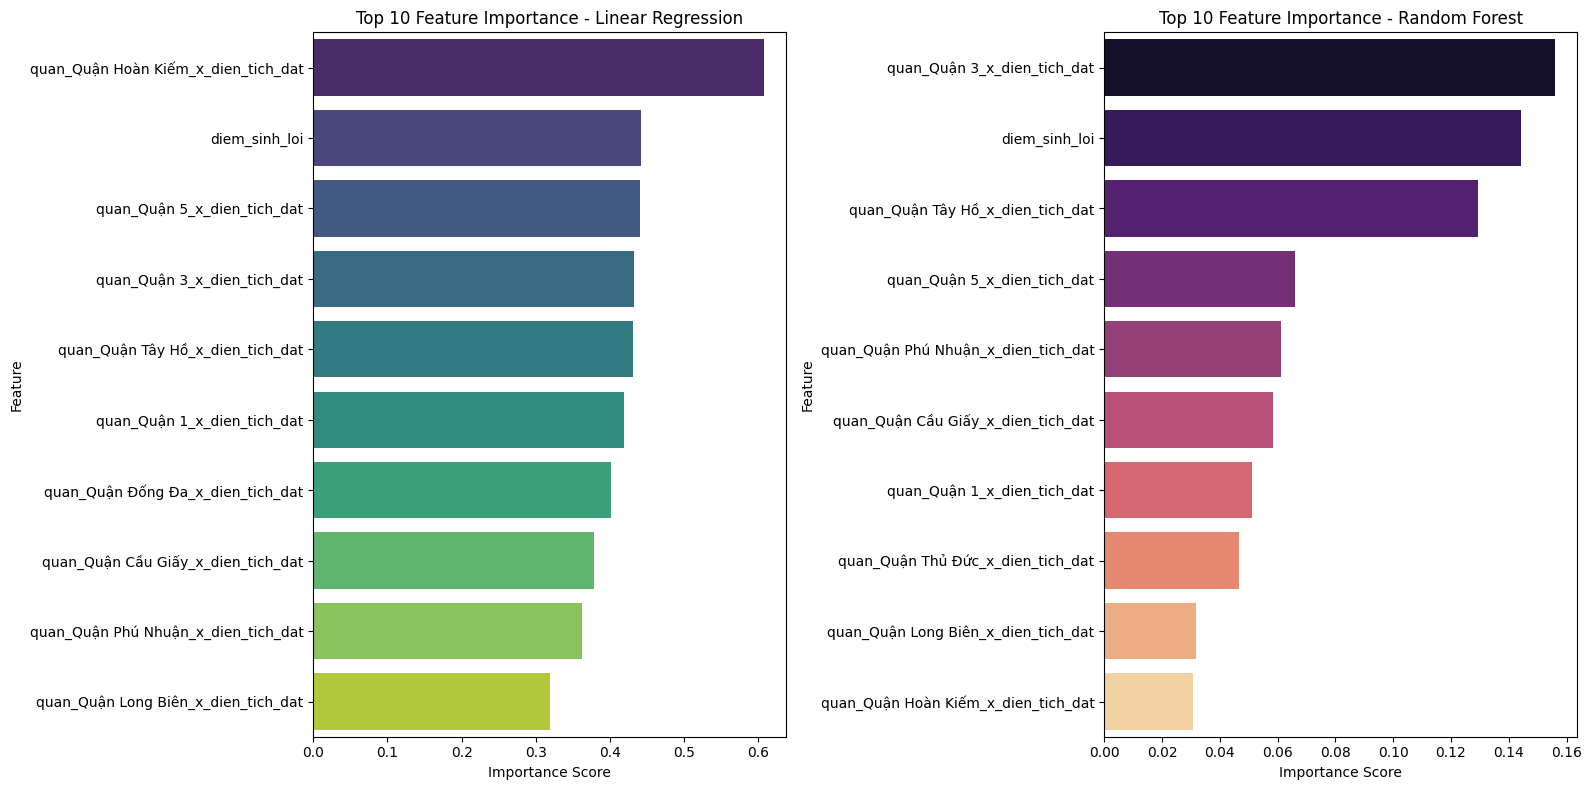

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu quan trọng 
lr_importance = pd.DataFrame({
    'Feature': X_train_features.columns,
    'Importance': np.abs(lin_reg.coef_)
}).sort_values(by='Importance', ascending=False)

rf_importance = pd.DataFrame({
    'Feature': X_train_features.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Vẽ biểu đồ 
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ Linear Regression
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=lr_importance.head(10), 
    ax=axes[0], 
    palette='viridis', 
    hue='Feature', 
    legend=False
)
axes[0].set_title('Top 10 Feature Importance - Linear Regression')
axes[0].set_xlabel('Importance Score') # Đã chỉnh sửa thành Importance Score

# Biểu đồ Random Forest
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=rf_importance.head(10), 
    ax=axes[1], 
    palette='magma', 
    hue='Feature', 
    legend=False
)
axes[1].set_title('Top 10 Feature Importance - Random Forest')
axes[1].set_xlabel('Importance Score') # Giữ nguyên Importance Score

plt.tight_layout()
plt.show()


### 4. Phân tích Feature Importance trong 2 thuật toán của mô hình 1

#### 4.1. Mô hình Linear Regression 

* **Sự áp đảo của Quận Hoàn Kiếm**: Đặc trưng `quan_Quận Hoàn Kiếm_x_dien_tich_dat` có điểm quan trọng cao nhất (vượt mốc 0.6). Điều này phản ánh thực tế thị trường: Hoàn Kiếm là khu vực có đơn giá đất cao bậc nhất, nên mỗi mét vuông đất tăng thêm tại đây sẽ làm tổng giá trị căn nhà tăng mạnh hơn so với bất kỳ quận nào khác.

* **Tính ổn định của các quận trung tâm**: Các biến tương tác của Quận 5, Quận 3, Quận 1 (TP.HCM) và Tây Hồ, Đống Đa (Hà Nội) đều nằm trong Top đầu với mức độ ảnh hưởng tương đối đồng đều (khoảng 0.4 - 0.45).

* **Vai trò của nội tại căn nhà**: Biến `diem_sinh_loi` xếp vị trí thứ 2. Điều này cho thấy sau yếu tố vị trí, các đặc điểm vật lý (số tầng, số phòng, diện tích sử dụng) đóng vai trò quan trọng tiếp theo trong việc định giá.

#### 4.2. Mô hình Random Forest 

* **Sự thay đổi thứ bậc**: Khác với Linear Regression, Random Forest đánh giá `quan_Quận 3_x_dien_tich_dat` là quan trọng nhất, theo sau rất sát là `diem_sinh_loi` và `quan_Quận Tây Hồ_x_dien_tich_dat`.

* **Khả năng phân loại**: Điểm số của Random Forest được phân bổ dàn trải hơn (từ 0.03 đến 0.16). Việc `diem_sinh_loi` có thứ hạng rất cao (thứ 2) ở mô hình này cho thấy đây là biến có khả năng "chia tách" dữ liệu cực tốt, giúp mô hình giảm thiểu sai số dự báo hiệu quả.

* **Sự xuất hiện và biến mất của các quận**: So với Linear Regression, Top 10 của Random Forest xuất hiện thêm Quận Thủ Đức, trong khi Quận Hoàn Kiếm tụt hạng xuống vị trí cuối cùng và Quận Đống Đa biến mất khỏi danh sách. Điều này cho thấy thuật toán Random Forest bắt được các mối quan hệ phi tuyến tính tại các khu vực có sự biến động giá đa dạng hơn, đồng thời đánh giá lại tầm quan trọng của các quận theo khả năng phân tách dữ liệu thay vì chỉ dựa vào hệ số tuyến tính.

## Mô hình 2

### Chuẩn bị bộ đặc trưng (Feature Set 2)

#### Mục tiêu
Bộ đặc trưng này được xây dựng nhằm kiểm tra giả thuyết rằng **ngoài các thuộc tính vật lý và vị trí**, thì **thông tin mô tả trong tiêu đề tin đăng bất động sản** cũng chứa các tín hiệu quan trọng ảnh hưởng đến giá nhà.

#### 1. Tiền xử lý dữ liệu
- Sử dụng dữ liệu đã được làm sạch và loại bỏ outlier từ bước tiền xử lý trước đó.
- Sao chép dữ liệu gốc để đảm bảo các bộ đặc trưng khác nhau được xây dựng độc lập.
- Cột `tieu_de` được chuẩn hóa bằng cách:
  - Thay thế giá trị khuyết bằng chuỗi rỗng.
  - Chuyển toàn bộ về chữ thường để thuận tiện cho việc trích xuất từ khóa.

#### 2. Đặc trưng số (Numeric Features)
Các đặc trưng số mô tả trực tiếp quy mô và chất lượng của bất động sản:
- `dien_tich_dat`: diện tích đất (m²)
- `phong_ngu`: số phòng ngủ
- `phong_tam`: số phòng tắm
- `so_tang`: số tầng
- `gia_tren_m2`: giá trên mỗi mét vuông
- `diem_sinh_loi`: điểm đánh giá tiềm năng sinh lợi <br>
Nhóm đặc trưng này phản ánh **giá trị nội tại** của bất động sản và thường có mối quan hệ trực tiếp với giá bán.

#### 3. Đặc trưng phân loại (Categorical Features)
Các đặc trưng phân loại được sử dụng gồm:

- `quan`: quận/huyện
- `thanh_pho`: thành phố
- `phap_ly`: tình trạng pháp lý<br>

Những đặc trưng này đại diện cho **vị trí địa lý** và **mức độ an toàn pháp lý**, hai yếu tố có ảnh hưởng lớn đến quyết định mua bán và định giá bất động sản.  
Các biến phân loại được mã hóa bằng **One-Hot Encoding** để phù hợp với các mô hình học máy.


#### 4. Đặc trưng từ khóa từ tiêu đề (Keyword-based Features)
Tiêu đề tin đăng thường chứa các thông tin mang tính **quảng bá hoặc nhấn mạnh ưu điểm** của bất động sản.  <br>
Từ đó, một tập các từ khóa phổ biến được trích xuất và chuyển thành các biến nhị phân (0/1), bao gồm:

- `ban_gap`, `giam_gia`, `gia_mem`: phản ánh áp lực bán và mức độ thương lượng giá
- `mat_tien`, `hai_mat_tien`, `ba_mat_tien`, `hai_mat_hem`, `nha_goc`, `hem_xe_hoi`: mô tả vị trí và khả năng tiếp cận
- `trung_tam`: mức độ thuận tiện về vị trí
- `nha_moi`, `dep`, `full_noi_that`: chất lượng và tình trạng bất động sản
- `dong_tien`, `chdv`: khả năng khai thác cho thuê
- `chinh_chu`: độ tin cậy của nguồn tin
- `biet_thu`: loại hình bất động sản, biệt thự thì sẽ có giá nhỉnh hơn <br>
Mỗi từ khóa được mã hóa thành một biến nhị phân, cho biết sự xuất hiện hoặc không xuất hiện của từ khóa đó trong tiêu đề tin đăng.

#### 5. Lý do lựa chọn bộ đặc trưng
Bộ đặc trưng này được lựa chọn dựa trên các cơ sở sau:

- Kết hợp cả **thông tin định lượng** (diện tích, số phòng, giá/m²) và **thông tin định tính** (mô tả ngôn ngữ trong tiêu đề).
- Phản ánh cách người bán truyền tải giá trị bất động sản thông qua nội dung quảng cáo.
- Cho phép kiểm tra mức độ đóng góp của các tín hiệu ngôn ngữ so với các đặc trưng truyền thống.
- Phù hợp để đánh giá cả mô hình tuyến tính (Linear Regression) và mô hình phi tuyến (Random Forest).

Thông qua bộ đặc trưng này, nghiên cứu nhằm đánh giá liệu việc bổ sung thông tin từ tiêu đề tin đăng có giúp cải thiện khả năng dự đoán giá nhà hay không.


In [11]:
# =========================
# FEATURE SET 2: keyword + numeric + categorical
# =========================

df_fs2 = df.copy()
df_fs2["tieu_de"] = df_fs2["tieu_de"].fillna("").str.lower()

KEYWORDS = {
    "ban_gap": ["bán gấp"],
    "giam_gia": ["giảm", "giảm nhanh"],
    "gia_mem": ["giá mềm", "nhỉnh", "chỉ"],
    "mat_tien": ["mặt tiền", "mt"],
    "ba_mat_tien": ["3 mặt tiền", "3 mt"],
    "hai_mat_tien": ["2 mặt tiền", "hai mặt tiền", "2 mt"],
    "hai_mat_hem": ["2 mặt hẻm", " hai mặt hẻm"],
    "nha_goc": ["góc"],
    "hem_xe_hoi": ["hẻm xe hơi"],
    "trung_tam": ["trung tâm"],
    "nha_moi": ["nhà mới"],
    "dep": ["đẹp"],
    "full_noi_that": ["full nội thất"],
    "dong_tien": ["dòng tiền", "thu "],
    "chdv": ["chdv", "căn hộ dịch vụ"],
    "chinh_chu": ["chính chủ"],
    "biet_thu": ["biệt thự"],
}

def onehot_from_title(text, keyword_map):
    return {
        col: int(any(kw in text for kw in kws))
        for col, kws in keyword_map.items()
    }

onehot_df_fs2 = df_fs2["tieu_de"].apply(
    lambda x: pd.Series(onehot_from_title(x, KEYWORDS))
)

df_fs2 = pd.concat([df_fs2, onehot_df_fs2], axis=1)

# ---- Feature definition ----
numeric_features_fs2 = [
    "dien_tich_dat",
    "phong_ngu",
    "phong_tam",
    "so_tang",
    "gia_tren_m2",
    "diem_sinh_loi"
]

categorical_features_fs2 = [
    "phap_ly",
    "quan",
    "thanh_pho"
]

keyword_features_fs2 = list(KEYWORDS.keys())

X_fs2 = df_fs2[
    numeric_features_fs2
    + categorical_features_fs2
    + keyword_features_fs2
]
y_fs2 = df_fs2["gia"]

# ---- Train / Test split ----
from sklearn.model_selection import train_test_split

X_train_fs2, X_test_fs2, y_train_fs2, y_test_fs2 = train_test_split(
    X_fs2, y_fs2, test_size=0.2, random_state=42
)

# ---- Preprocess + Linear Regression ----
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preprocess_fs2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_fs2 + keyword_features_fs2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_fs2),
    ]
)

lin_model_fs2 = Pipeline(
    steps=[
        ("preprocess", preprocess_fs2),
        ("regressor", LinearRegression())
    ]
)

lin_model_fs2.fit(X_train_fs2, y_train_fs2)
y_pred_lin_fs2 = lin_model_fs2.predict(X_test_fs2)

print("FEATURE SET 2 - LINEAR REGRESSION")
print("RMSE:", np.sqrt(mean_squared_error(y_test_fs2, y_pred_lin_fs2)))
print("MAE:", mean_absolute_error(y_test_fs2, y_pred_lin_fs2))
print("R2:", r2_score(y_test_fs2, y_pred_lin_fs2))

# ---- Coefficient analysis ----
feature_names_fs2 = lin_model_fs2.named_steps[
    "preprocess"
].get_feature_names_out()

coef_fs2 = lin_model_fs2.named_steps["regressor"].coef_

coef_df_fs2 = (
    pd.DataFrame({"feature": feature_names_fs2, "coef": coef_fs2})
    .sort_values(by="coef", ascending=False)
)

# ---- Random Forest ----
from sklearn.ensemble import RandomForestRegressor

rf_model_fs2 = Pipeline(
    steps=[
        ("preprocess", preprocess_fs2),
        ("regressor", RandomForestRegressor(
            # n_estimators=500,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model_fs2.fit(X_train_fs2, y_train_fs2)
y_pred_rf_fs2 = rf_model_fs2.predict(X_test_fs2)

print("\nFEATURE SET 2 - RANDOM FOREST")
print("RMSE:", np.sqrt(mean_squared_error(y_test_fs2, y_pred_rf_fs2)))
print("MAE:", mean_absolute_error(y_test_fs2, y_pred_rf_fs2))
print("R2:", r2_score(y_test_fs2, y_pred_rf_fs2))


FEATURE SET 2 - LINEAR REGRESSION
RMSE: 14.84909491071278
MAE: 5.806028493449924
R2: 0.7168678770331425

FEATURE SET 2 - RANDOM FOREST
RMSE: 7.692251633426784
MAE: 0.9269987900751426
R2: 0.924020550169284


### Nhận xét chi tiết về kết quả so sánh 2 thuật toán của mô hình 2

#### 1. Phân tích các chỉ số đánh giá của 2 thuật toán

##### 1.1. Root Mean Squared Error (RMSE)
**Linear Regression: 14.85  | Random Forest: 7.69**

- Random Forest có RMSE thấp hơn rất nhiều so với Linear Regression, cho thấy mô hình này dự đoán chính xác hơn đáng kể về tổng thể.
- RMSE là chỉ số nhạy cảm với các sai số lớn. Việc Random Forest đạt RMSE chỉ 7.69 (giảm gần 50% so với Linear Regression) cho thấy mô hình này xử lý **rất tốt các trường hợp giá nhà cao hoặc các mẫu có đặc điểm đặc biệt**.
- Với bối cảnh giá nhà dao động từ 0.5 đến 500 tỷ, RMSE 7.69 tỷ là mức sai lệch tương đối thấp và có ý nghĩa thực tiễn cao.
- Ngược lại, Linear Regression có RMSE cao hơn cho thấy mô hình tuyến tính gặp hạn chế khi phải mô hình hóa các mối quan hệ phức tạp trong bộ feature hiện tại.

##### 1.2. Mean Absolute Error (MAE)
**Linear Regression: 5.81 | Random Forest: 0.93**

- Random Forest vượt trội hoàn toàn với MAE chỉ **0.93**, thấp hơn rất nhiều so với Linear Regression (**5.81**).
- MAE phản ánh sai số trung bình mà người dùng thực tế sẽ gặp phải. Kết quả này cho thấy với Random Forest, một dự đoán giá nhà trung bình chỉ sai lệch dưới 1 tỷ đồng.
- Mức chênh lệch **gần 5 tỷ đồng** giữa hai mô hình là cực kỳ lớn trong thực tế, đặc biệt với các căn nhà thuộc phân khúc trung bình và thấp.
- Điều này cho thấy Random Forest dự đoán **rất chính xác với phần lớn các trường hợp phổ biến**, và gần như không bị ảnh hưởng bởi nhiễu hay outliers trong dữ liệu.

##### 1.3. R² Score (Hệ số xác định)
**Linear Regression: 0.7169 | Random Forest: 0.9240**

- Random Forest giải thích được **92.40%** biến động của giá nhà, vượt trội so với Linear Regression (**71.69%**).
- Chênh lệch hơn **20% R²** là rất lớn, cho thấy Random Forest nắm bắt được cấu trúc dữ liệu và mối quan hệ giữa các đặc trưng tốt hơn hẳn.
- R² gần 0.93 là kết quả rất cao đối với bài toán dự đoán giá bất động sản, vốn chịu ảnh hưởng của nhiều yếu tố khó quan sát.
- Kết quả này cho thấy bộ feature hiện tại có **mối quan hệ phi tuyến mạnh với giá nhà**, và Random Forest tận dụng được điều này hiệu quả hơn Linear Regression.

#### 2. Kết luận về hiệu suất từng thuật toán

##### 2.1. Linear Regression

**Điểm mạnh:**  
- Dễ triển khai và dễ giải thích  
- Hiệu suất ở mức chấp nhận được (R² > 0.7)  
- Phù hợp làm mô hình baseline

**Điểm yếu:**  
- Không mô hình hóa được mối quan hệ phi tuyến giữa các đặc trưng  
- Hiệu suất kém rõ rệt khi dữ liệu chứa nhiều tín hiệu phức tạp từ keyword và categorical features  
- RMSE và MAE cao hơn đáng kể so với Random Forest

##### 2.2. Random Forest

**Điểm mạnh:**  
- Hiệu suất vượt trội trên tất cả các chỉ số (RMSE, MAE, R²)  
- Mô hình hóa tốt các mối quan hệ phi tuyến và tương tác phức tạp giữa:
  - Đặc trưng số
  - Vị trí địa lý
  - Thông tin pháp lý
  - Tín hiệu ngôn ngữ từ tiêu đề tin đăng  
- Sai số trung bình cực thấp, phù hợp với ứng dụng thực tế

**Điểm yếu:**  
- Mô hình phức tạp hơn  
- Khó giải thích trực quan so với Linear Regression  
- Chi phí tính toán cao hơn

##### **Hiệu suất tổng thể: Random Forest vượt trội hơn rõ rệt so với Linear Regression**

#### 3. Kết luận chung và lựa chọn thuật toán

**Mô hình được chọn: Random Forest**

Dựa trên phân tích trên, **Random Forest** là lựa chọn tối ưu cho bộ feature này vì:

1. **Hiệu suất vượt trội toàn diện**: R² cao hơn hơn 20%, RMSE giảm gần một nửa, MAE giảm xuống dưới 1 tỷ
2. **Mô hình hóa tốt dữ liệu phức tạp**: Khai thác hiệu quả các tín hiệu phi tuyến từ keyword, vị trí và pháp lý
3. **Độ chính xác thực tiễn cao**: Sai số trung bình rất thấp, phù hợp với nhu cầu dự đoán giá nhà trong thực tế
4. **Phù hợp với bản chất bộ feature**: Bộ feature kết hợp giữa dữ liệu định lượng và thông tin ngôn ngữ, vốn không tuân theo giả định tuyến tính
5. **Khả năng tổng quát tốt**: Kết quả R² cao cho thấy mô hình học được cấu trúc dữ liệu ổn định

Trong khi Linear Regression vẫn có vai trò làm mô hình baseline, nó không đủ khả năng khai thác hết thông tin chứa trong bộ feature này.  

**Kết quả cuối cùng**: Random Forest với **R² = 0.9240, RMSE = 7.69 tỷ, MAE = 0.91 tỷ** là mô hình phù hợp nhất để triển khai và sử dụng trong thực tế cho bộ feature này.


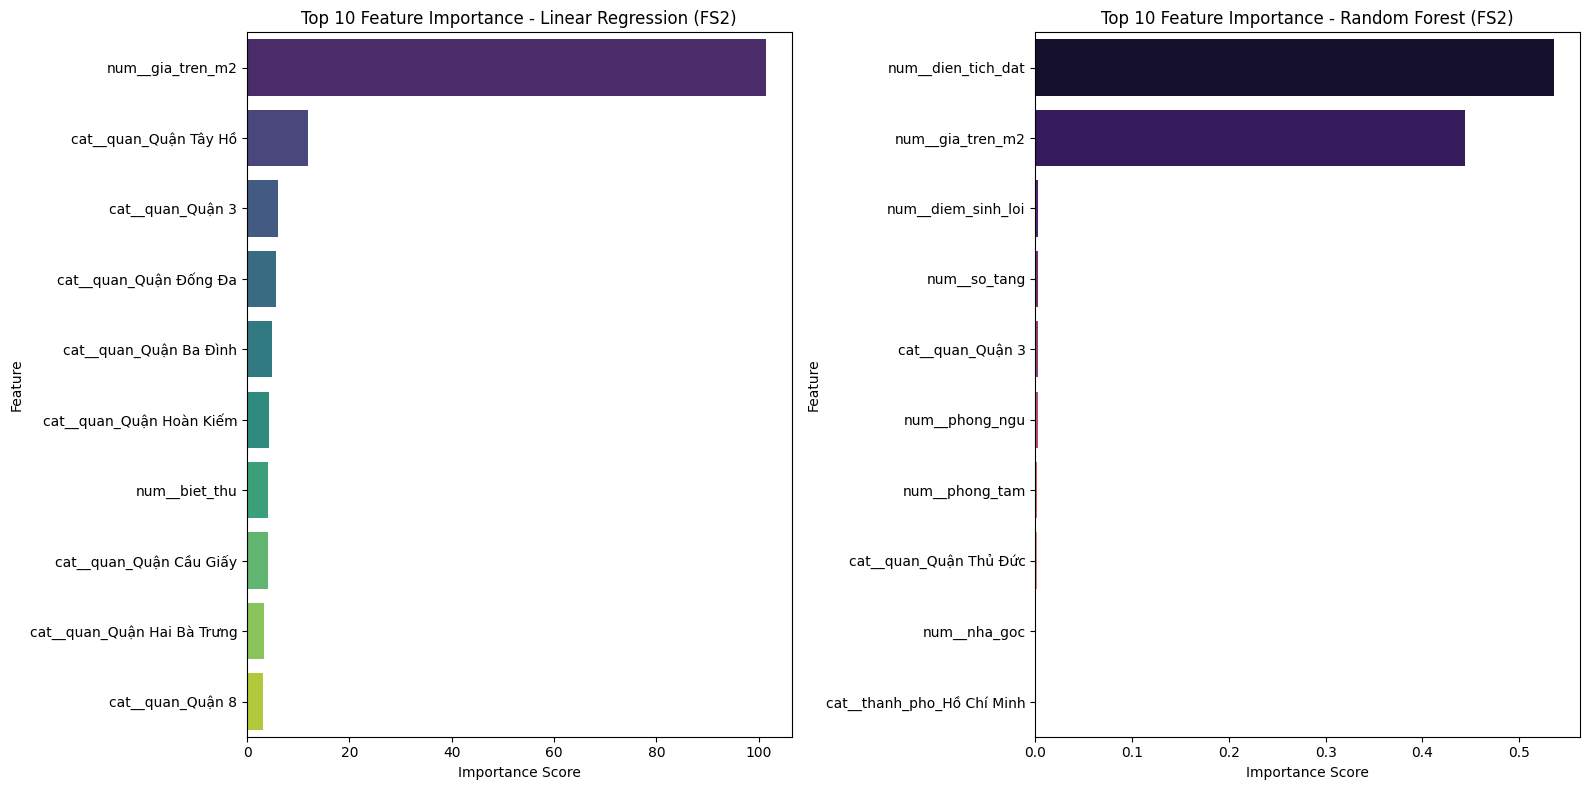

In [14]:
# ---- Linear Regression feature importance ----
feature_names_fs2 = lin_model_fs2.named_steps[
    "preprocess"
].get_feature_names_out()

lr_importance_fs2 = (
    pd.DataFrame({
        "Feature": feature_names_fs2,
        "Importance": np.abs(
            lin_model_fs2.named_steps["regressor"].coef_
        )
    })
    .sort_values(by="Importance", ascending=False)
)
# ---- Random Forest feature importance ----
rf_importance_fs2 = (
    pd.DataFrame({
        "Feature": feature_names_fs2,
        "Importance": rf_model_fs2.named_steps[
            "regressor"
        ].feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ---- Linear Regression ----
sns.barplot(
    x="Importance",
    y="Feature",
    data=lr_importance_fs2.head(10),
    ax=axes[0],
    palette="viridis",
    hue="Feature",
    legend=False
)
axes[0].set_title("Top 10 Feature Importance - Linear Regression (FS2)")
axes[0].set_xlabel("Importance Score")

# ---- Random Forest ----
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance_fs2.head(10),
    ax=axes[1],
    palette="magma",
    hue="Feature",
    legend=False
)
axes[1].set_title("Top 10 Feature Importance - Random Forest (FS2)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


### 4. Phân tích Feature Importance trong 2 thuật toán của mô hình Feature Set 2 (FS2)

#### 4.1. Mô hình Linear Regression

* **Sự chi phối của `gia_tren_m2`**: Feature **`num__gia_tren_m2`** có mức độ quan trọng vượt trội, cho thấy mối quan hệ tuyến tính rất mạnh giữa giá tổng thể và giá trên mỗi mét vuông – yếu tố cốt lõi trong định giá bất động sản.

* **Tầm quan trọng của vị trí hành chính**: Các biến thuộc nhóm **`quan`** (*Tây Hồ, Quận 3, Đống Đa, Ba Đình, Hoàn Kiếm*) đều nằm trong Top 10, phản ánh ảnh hưởng rõ rệt của vị trí đến giá nhà.

* **Vai trò bổ trợ của keyword**: Feature **`num__biet_thu`** xuất hiện với mức độ ảnh hưởng thấp hơn, cho thấy các keyword mô tả loại hình nhà ở đóng vai trò hỗ trợ trong mô hình tuyến tính.

#### 4.2. Mô hình Random Forest

* **Ưu tiên diện tích và giá trị nội tại**: Random Forest đánh giá **`num__dien_tich_dat`** là quan trọng nhất, theo sau là **`num__gia_tren_m2`**, cho thấy khả năng phân tách mạnh của các biến này trong mô hình cây.

* **Phân bổ lại mức độ quan trọng**: So với Linear Regression, Random Forest tập trung độ quan trọng vào một vài biến chính, trong khi các biến như **số tầng**, **số phòng** và **điểm sinh lợi** chỉ đóng vai trò bổ trợ.

* **Khác biệt trong đánh giá vị trí**: Một số quận như **Quận 3** và **Thủ Đức** xuất hiện trong Top 10, trong khi các quận trung tâm khác không còn giữ vị trí cao, phản ánh khả năng bắt quan hệ phi tuyến của Random Forest.


### Tinh chỉnh siêu tham số trên mô hình Random Forest cho bộ feature 2
- Dùng GridSearchCV
- Thử với các bộ tham số của random forest lần lượt:
    - n_estimator: 50 100 200
    - max_depth: 3,4,5,6,7

Ở đây sẽ lấy RMSE làm tiêu chí đánh giá vì RMSE phạt nặng các dự đoán sai lệch, sau khi chạy thì bộ tham số nào cho RMSE thấp nhất là tốt nhất.


In [13]:
# =========================
# GRID SEARCH CV - RANDOM FOREST (FEATURE SET 2)
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------
# 1. Pipeline
# -------------------------
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_fs2),
        ("regressor", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# -------------------------
# 2. Hyperparameter grid
# -------------------------
param_grid = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [3, 4, 5, 6, 7]
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4]
}

# -------------------------
# 3. GridSearchCV
# -------------------------
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# -------------------------
# 4. Fit
# -------------------------
grid_search.fit(X_train_fs2, y_train_fs2)

# -------------------------
# 5. CV results (MEAN ONLY)
# -------------------------
results_df = pd.DataFrame(grid_search.cv_results_)

summary_df = results_df[
    [
        "param_regressor__n_estimators",
        "param_regressor__max_depth",
        "mean_test_score"
    ]
].copy()

summary_df["RMSE_CV_mean"] = -summary_df["mean_test_score"]
summary_df = summary_df.drop(columns="mean_test_score")

summary_df = summary_df.sort_values(
    by="RMSE_CV_mean"
).reset_index(drop=True)

print("\nRMSE FOR EACH (n_estimators, max_depth):\n")

for _, row in summary_df.iterrows():
    print(
        f"n_estimators = {int(row['param_regressor__n_estimators'])}, "
        f"max_depth = {int(row['param_regressor__max_depth'])} "
        f"--> RMSE_CV_mean = {row['RMSE_CV_mean']:.4f}"
    )

# -------------------------
# 7. Best model
# -------------------------
print("\nBEST PARAMETERS:")
print(grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

# -------------------------
# 8. Test set evaluation
# -------------------------
y_pred_test = best_rf_model.predict(X_test_fs2)

print("\nFINAL MODEL PERFORMANCE (TEST SET)")
print("RMSE:", np.sqrt(mean_squared_error(y_test_fs2, y_pred_test)))
print("MAE:", mean_absolute_error(y_test_fs2, y_pred_test))
print("R2:", r2_score(y_test_fs2, y_pred_test))


Fitting 5 folds for each of 15 candidates, totalling 75 fits

RMSE FOR EACH (n_estimators, max_depth):

n_estimators = 200, max_depth = 7 --> RMSE_CV_mean = 4.5203
n_estimators = 100, max_depth = 7 --> RMSE_CV_mean = 4.5327
n_estimators = 50, max_depth = 7 --> RMSE_CV_mean = 4.6560
n_estimators = 100, max_depth = 6 --> RMSE_CV_mean = 4.8674
n_estimators = 200, max_depth = 6 --> RMSE_CV_mean = 4.8807
n_estimators = 50, max_depth = 6 --> RMSE_CV_mean = 5.0097
n_estimators = 200, max_depth = 5 --> RMSE_CV_mean = 5.7884
n_estimators = 100, max_depth = 5 --> RMSE_CV_mean = 5.7942
n_estimators = 50, max_depth = 5 --> RMSE_CV_mean = 5.7980
n_estimators = 50, max_depth = 4 --> RMSE_CV_mean = 7.1565
n_estimators = 100, max_depth = 4 --> RMSE_CV_mean = 7.1805
n_estimators = 200, max_depth = 4 --> RMSE_CV_mean = 7.1861
n_estimators = 50, max_depth = 3 --> RMSE_CV_mean = 9.4680
n_estimators = 100, max_depth = 3 --> RMSE_CV_mean = 9.5359
n_estimators = 200, max_depth = 3 --> RMSE_CV_mean = 9.5542



Các siêu tham số được lựa chọn bằng phương pháp grid search không cho ra kết quả tốt hơn so với siêu tham số mặc định của thư viện hơn thế việc sử dụng siêu tham số mặc định của thư viện cũng chạy rất nhanh nên dùng tham số mặc định để dự đoán